In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
import random
random.seed(118)

In [21]:
path="/Users/mattgonzales/Downloads/Labeled Turnips - turnip_weekly_clean.csv"


In [22]:
turnip=pd.read_csv(path)
turnip = turnip.dropna()
turnip.isna().sum()

week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [23]:
price_cols = turnip.columns[1:-1]  # all price columns

In [24]:
X = turnip[price_cols] 

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(turnip['Label'])

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
print("X Training:\n", X_train)

X Training:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
60        99.0       78.0      132.0       110.0         139           192   
24       106.0       53.0       49.0       124.0         119           151   
82        96.0       87.0       83.0        79.0          74            71   
49       100.0       91.0      129.0        91.0         131            75   
78        98.0       67.0       63.0        59.0         116            91   
..         ...        ...        ...         ...         ...           ...   
77       106.0       74.0       96.0       118.0         149           153   
16        91.0       64.0       59.0        83.0          56            47   
98        99.0       86.0       82.0        77.0          73            69   
56       105.0       93.0       88.0        84.0          80            76   
108      103.0      110.0      138.0       118.0         108           144   

     Wednesday_PM  Thursday_AM  Thursday_PM  Frida

In [32]:
print("X Testing:\n", X_test)

X Testing:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
32       108.0       95.0       90.0        87.0          84            80   
71       100.0       87.0       82.0        78.0          73            69   
70       105.0      143.0      125.0       150.0         154           149   
58        94.0       81.0       77.0        73.0          69           127   
50        91.0       79.0       87.0       179.0         329           157   
99       107.0       93.0       88.0        83.0          79            74   
97       108.0      131.0      146.0        68.0          61           130   
52        92.0       79.0       76.0        73.0          69            65   
12        91.0       78.0       75.0        71.0          68            66   
0         96.0       92.0       87.0        82.0          79            74   
20       105.0       94.0       89.0        85.0         140           151   
33        90.0       78.0       75.0        71.0    

In [33]:
print("Y Training:\n", y_train)

Y Training:
 [3 3 0 1 3 1 1 1 3 3 0 1 3 1 2 1 0 2 2 2 3 0 0 0 1 1 1 2 3 3 1 2 1 1 1 3 2
 1 2 0 3 2 0 1 3 1 2 2 1 0 1 1 3 2 1 2 2 0 1 1 0 3 3 1 2 3 3 3 2 0 2 1 2 1
 2 3 0 3 3 1 2 0 1]


In [34]:
print("Y Testing:\n", y_test)

Y Testing:
 [0 0 3 2 2 0 1 0 0 3 2 2 0 0 2 2 1 1 2 3 2]


In [27]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.5714285714285714
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.33      0.67      0.44         3
           2       0.80      0.50      0.62         8
           3       0.20      0.33      0.25         3

    accuracy                           0.57        21
   macro avg       0.58      0.55      0.54        21
weighted avg       0.71      0.57      0.61        21



In [29]:
tree_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_pruned.fit(X_train, y_train)

y_pred_pruned = tree_pruned.predict(X_test)

print("Pruned Accuracy:", accuracy_score(y_test, y_pred_pruned))

Pruned Accuracy: 0.5714285714285714


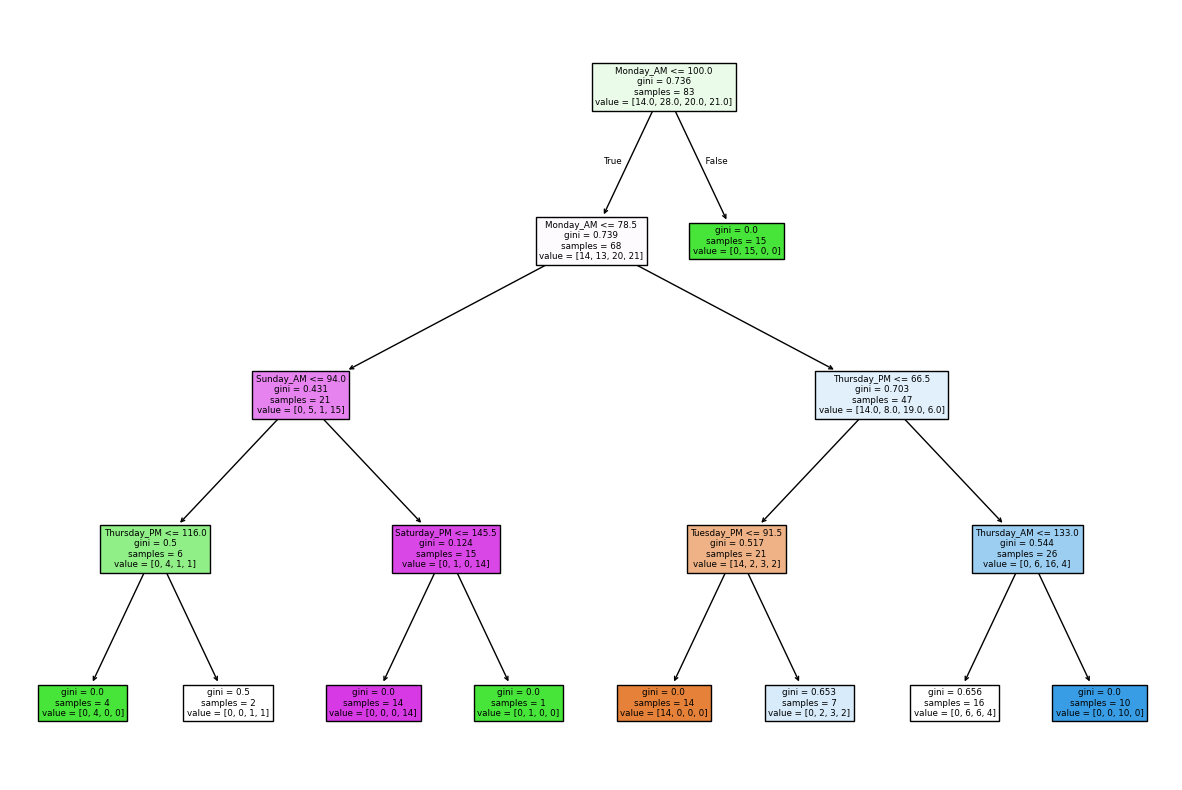

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(tree_pruned, feature_names=price_cols, filled=True)
plt.show()

In [51]:
features_thu = [
    'Thursday_AM', 'Thursday_PM',
    'Friday_AM', 'Friday_PM',
    'Saturday_AM', 'Saturday_PM'
]

tree_thu = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_thu.fit(X_train[features_thu], y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

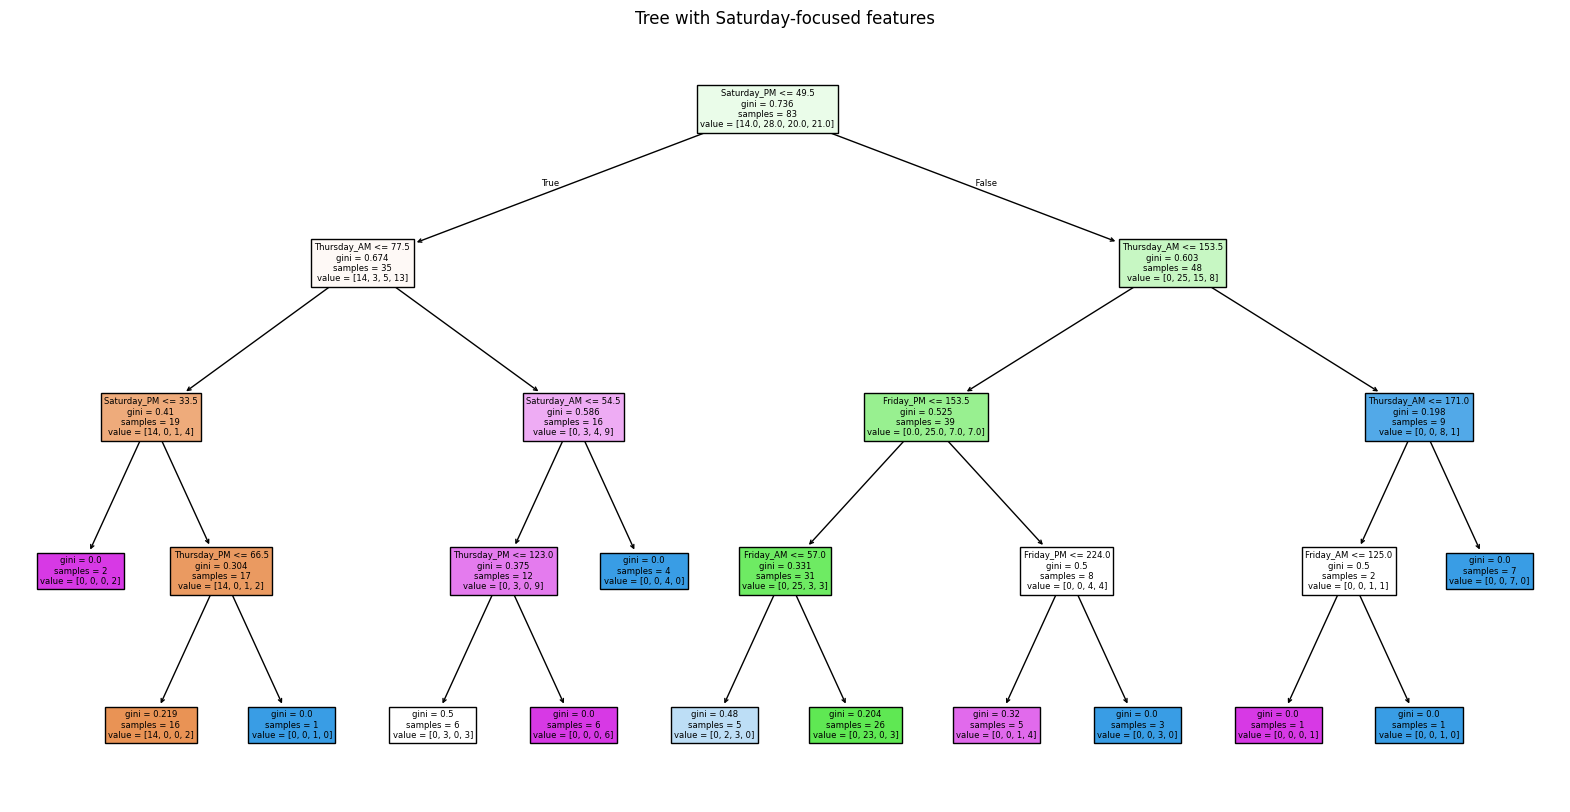

In [55]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree_thu, feature_names=features_thu, filled=True)
plt.title("Tree with Saturday-focused features")
plt.show()

In [56]:
from sklearn.metrics import accuracy_score

y_pred_thu = tree_thu.predict(X_test[features_thu])

accuracy_thu = accuracy_score(y_test, y_pred_thu)
print("Accuracy:", accuracy_thu)

Accuracy: 0.5714285714285714


In [53]:
features_wed = [
    'Wednesday_PM', 'Wednesday_AM',
    'Tuesday_PM', 'Thursday_AM'
]

tree_wed = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_wed.fit(X_train[features_wed], y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

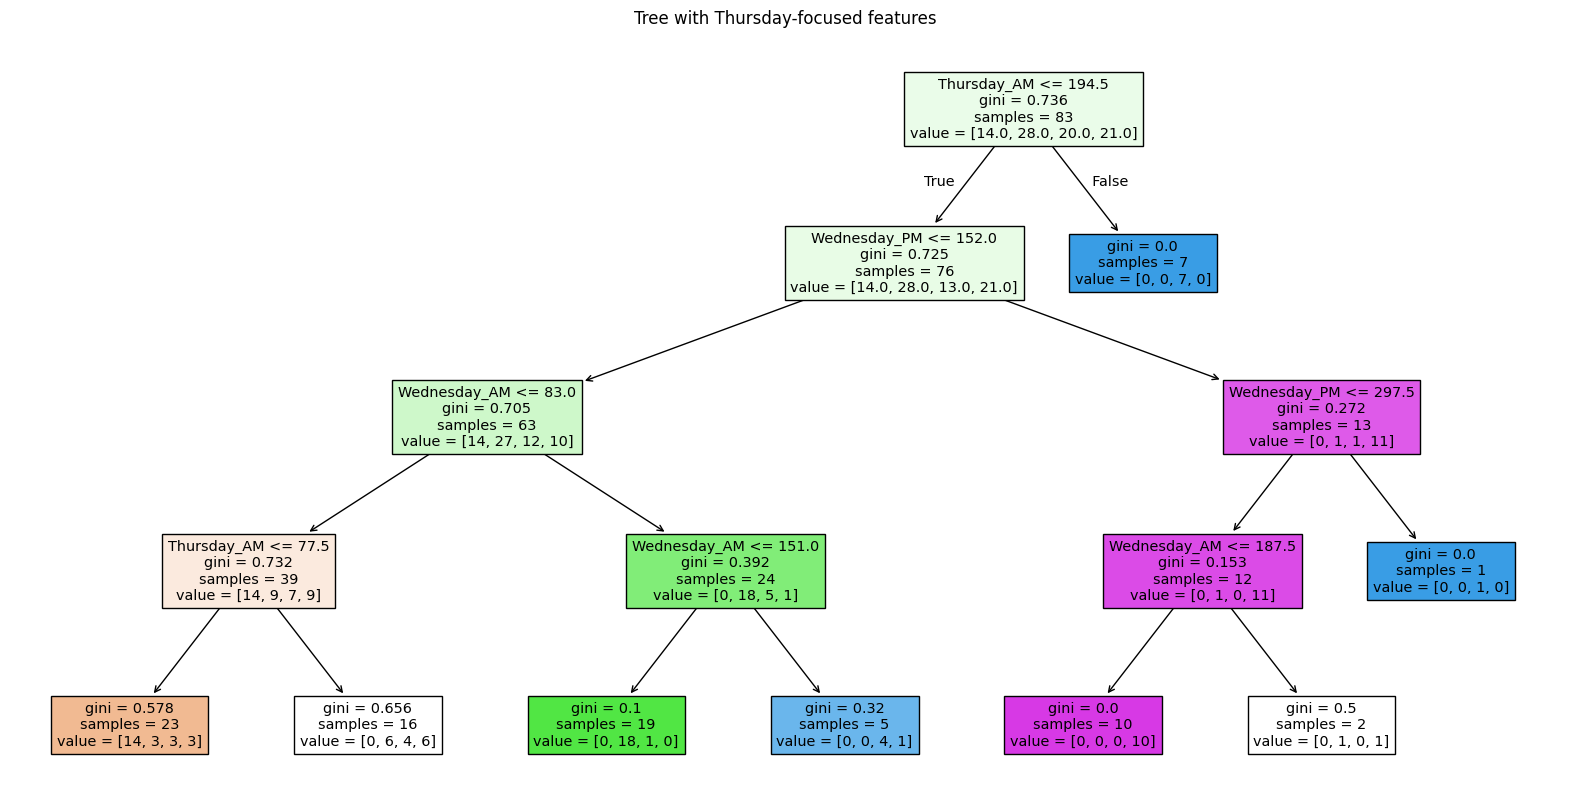

In [62]:
plt.figure(figsize=(20,10))
plot_tree(tree_wed, feature_names=features_wed, filled=True)
plt.title("Tree with Thursday-focused features")
plt.show()

In [61]:
from sklearn.metrics import accuracy_score

y_pred_wed = tree_wed.predict(X_test[features_wed])

accuracy_wed = accuracy_score(y_test, y_pred_wed)
print("Accuracy:", accuracy_wed)

Accuracy: 0.6190476190476191


[Text(0.5, 0.75, 'Monday_AM <= 49.5\ngini = 0.736\nsamples = 83\nvalue = [14.0, 28.0, 20.0, 21.0]'),
 Text(0.25, 0.25, 'gini = 0.674\nsamples = 35\nvalue = [14, 3, 5, 13]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.603\nsamples = 48\nvalue = [0, 25, 15, 8]'),
 Text(0.625, 0.5, '  False')]

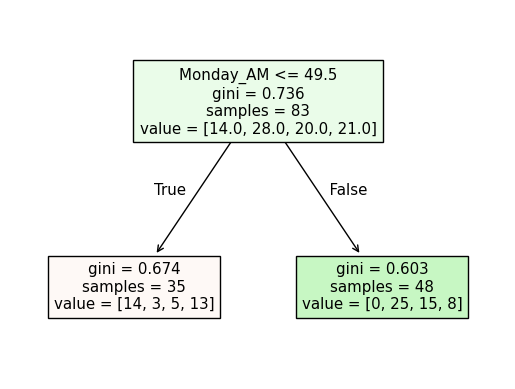

In [46]:
# plot_tree(tree1, feature_names=features_1, filled=True)
plot_tree(tree2, feature_names=features_2, filled=True)
# plot_tree(tree3, feature_names=features_3, filled=True)

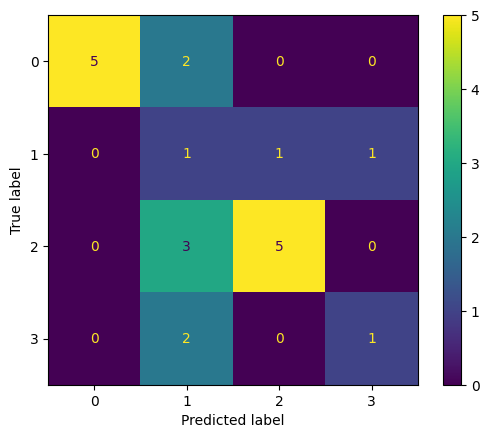

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_pruned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

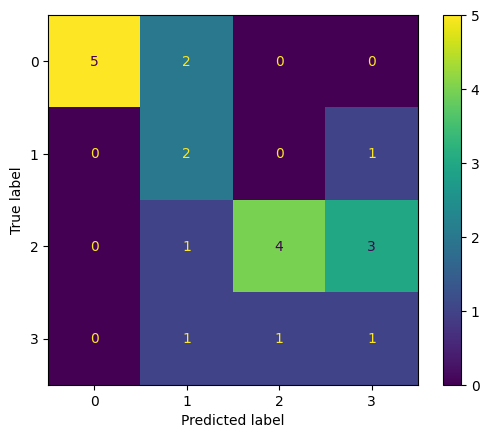

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()